# Restaurant Sales Insight

Companion notebook for this restaurant sales analysis workflow. Use it for walkthroughs, quick testing, and recruiter demos. The notebook loads the raw CSV, cleans the data, exports the reporting dataset, and generates key visual insights.

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)

def resolve_base_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent]

    for folder in candidates:
        if (folder / "data" / "restaurant_sales_raw.csv").exists():
            return folder

    raise FileNotFoundError(
        "Could not find data/restaurant_sales_raw.csv. Open this notebook from the Restaurant Sales Insight project folder."
    )

BASE_DIR = resolve_base_dir()
DATA_PATH = BASE_DIR / "data" / "restaurant_sales_raw.csv"
OUTPUT_PATH = BASE_DIR / "output" / "restaurant_sales_cleaned.csv"

print(f"Base directory: {BASE_DIR}")
print(f"Raw data path: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()


Base directory: D:\code\project portfolio\Restaurant Sales Insight
Raw data path: D:\code\project portfolio\Restaurant Sales Insight\data\restaurant_sales_raw.csv


,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin


## 1. Data Cleaning

In [15]:
df = df_raw.copy()
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

df["date"] = pd.to_datetime(df["date"], format="%d-%m-%Y", errors="coerce")
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

text_columns = ["product", "purchase_type", "payment_method", "manager", "city"]
for column in text_columns:
    df[column] = df[column].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()

df = df.dropna(subset=["date", "product", "price", "quantity"])
df = df.drop_duplicates(subset=["order_id"])

category_map = {
    "Beverages": "Beverage",
    "Burgers": "Main Course",
    "Chicken Sandwiches": "Main Course",
    "Fries": "Sides",
    "Sides & Other": "Sides",
}

df["product_category"] = df["product"].map(category_map).fillna("Other")
df["revenue"] = (df["price"] * df["quantity"]).round(2)
df["year"] = df["date"].dt.year
df["month_num"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["day_num"] = df["date"].dt.day
df["day_name"] = df["date"].dt.day_name()
df["week_num"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = df["day_name"].isin(["Saturday", "Sunday"])

df = df[[
    "order_id", "date", "year", "month_num", "month_name", "week_num", "day_num", "day_name",
    "is_weekend", "product", "product_category", "price", "quantity", "revenue",
    "purchase_type", "payment_method", "manager", "city"
]].sort_values(["date", "order_id"]).reset_index(drop=True)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_PATH, index=False)
df.head()


,order_id,date,year,month_num,month_name,week_num,day_num,day_name,is_weekend,product,product_category,price,quantity,revenue,purchase_type,payment_method,manager,city
0,10452,2022-11-07,2022,11,Nov,45,7,Monday,False,Fries,Sides,3.49,573.07,2000.01,Online,Gift Card,Tom Jackson,London
1,10453,2022-11-07,2022,11,Nov,45,7,Monday,False,Beverages,Beverage,2.95,745.76,2199.99,Online,Gift Card,Pablo Perez,Madrid
2,10454,2022-11-07,2022,11,Nov,45,7,Monday,False,Sides & Other,Sides,4.99,200.40,1000.00,In-store,Gift Card,Joao Silva,Lisbon
3,10455,2022-11-08,2022,11,Nov,45,8,Tuesday,False,Burgers,Main Course,12.99,569.67,7400.01,In-store,Credit Card,Walter Muller,Berlin
4,10456,2022-11-08,2022,11,Nov,45,8,Tuesday,False,Chicken Sandwiches,Main Course,9.95,201.01,2000.05,In-store,Credit Card,Walter Muller,Berlin


In [16]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())
print("Total revenue:", round(df["revenue"].sum(), 2))
print("Total orders:", df["order_id"].nunique())
print("Average order value:", round(df["revenue"].sum() / df["order_id"].nunique(), 2))


Rows: 254
Columns: 18
Date range: 2022-11-07 to 2022-12-29
Total revenue: 769515.89
Total orders: 254
Average order value: 3029.59


## 2. Exploratory Data Analysis

In [17]:
daily_sales = df.groupby("date", as_index=False)["revenue"].sum()
monthly_sales = df.groupby(["year", "month_num", "month_name"], as_index=False)["revenue"].sum()
product_sales = df.groupby("product", as_index=False).agg(
    total_revenue=("revenue", "sum"),
    total_quantity=("quantity", "sum"),
)
product_sales = product_sales.sort_values("total_revenue", ascending=False)
category_sales = df.groupby("product_category", as_index=False)["revenue"].sum().sort_values("revenue", ascending=False)
city_sales = df.groupby("city", as_index=False)["revenue"].sum().sort_values("revenue", ascending=False)

product_sales


,product,total_revenue,total_quantity
1,Burgers,376999.85,29022.31
3,Fries,125674.19,32034.34
2,Chicken Sandwiches,114641.67,11135.92
0,Beverages,103200.18,34983.14
4,Sides & Other,49000.00,9819.60


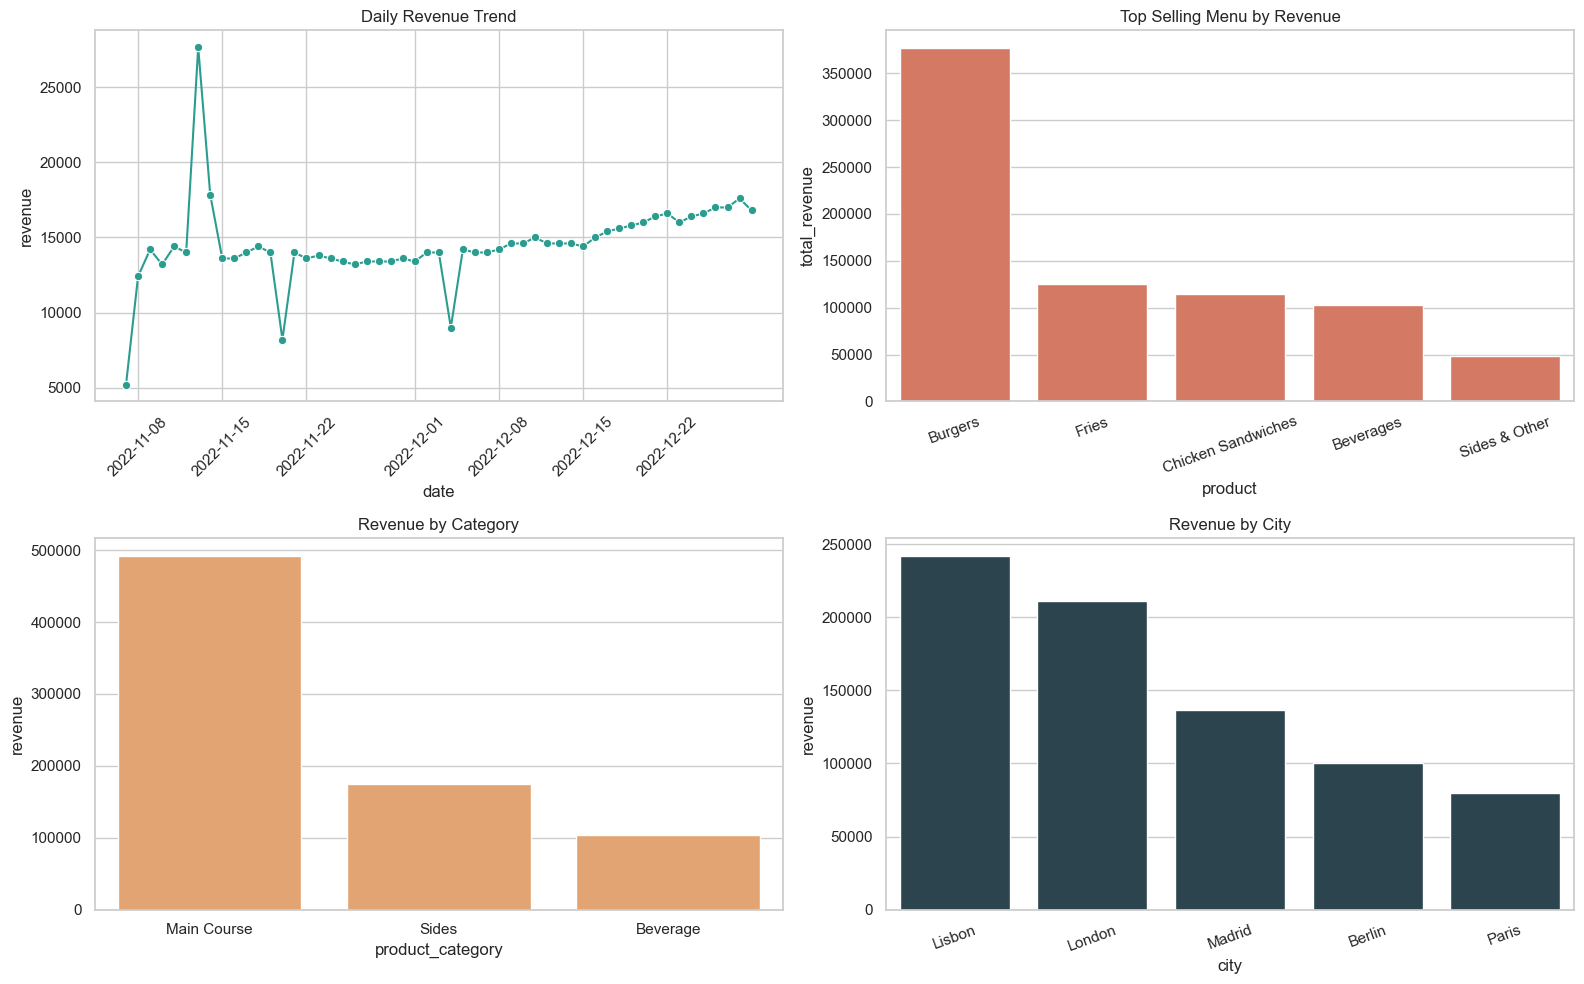

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.lineplot(data=daily_sales, x="date", y="revenue", marker="o", ax=axes[0, 0], color="#2a9d8f")
axes[0, 0].set_title("Daily Revenue Trend")
axes[0, 0].tick_params(axis="x", rotation=45)

sns.barplot(data=product_sales, x="product", y="total_revenue", ax=axes[0, 1], color="#e76f51")
axes[0, 1].set_title("Top Selling Menu by Revenue")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.barplot(data=category_sales, x="product_category", y="revenue", ax=axes[1, 0], color="#f4a261")
axes[1, 0].set_title("Revenue by Category")

sns.barplot(data=city_sales, x="city", y="revenue", ax=axes[1, 1], color="#264653")
axes[1, 1].set_title("Revenue by City")
axes[1, 1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


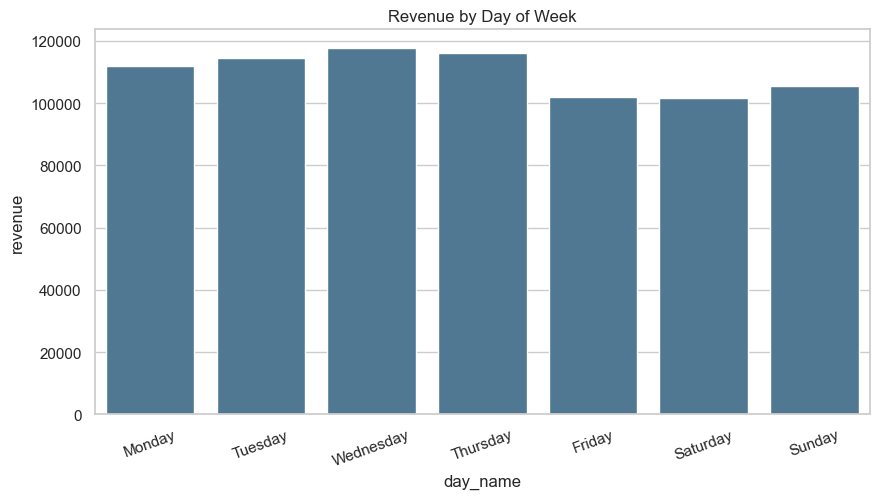

In [19]:
day_name_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_sales = df.groupby("day_name", as_index=False)["revenue"].sum()
day_sales["day_name"] = pd.Categorical(day_sales["day_name"], categories=day_name_order, ordered=True)
day_sales = day_sales.sort_values("day_name")

plt.figure(figsize=(10, 5))
sns.barplot(data=day_sales, x="day_name", y="revenue", color="#457b9d")
plt.title("Revenue by Day of Week")
plt.xticks(rotation=20)
plt.show()


## 3. Trend Analysis and Business Notes

- `Burgers` contributes the highest revenue and should remain the flagship menu.
- `Main Course` dominates category contribution, while beverages can be improved through bundle strategies.
- December revenue is higher than November, suggesting stronger year-end demand.
- The source dataset does not include transaction hour timestamps, so a true `sales by hour` analysis is not possible without richer POS data.